# TP2 - Informe tecnico

Sistema de Deteccion y Clasificacion de Razas de Perros — IA 5.2 Computer Vision.

## Equipo
- Alumno 1 : Calabozo Nicolás
- Alumno 2 : Lapolla Martín

In [2]:
from PIL import Image
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from collections import Counter
import json
import pandas as pd
import albumentations as A
import numpy as np
import os
import sys
from pathlib import Path
from IPython.display import display, HTML
#import seaborn as sns

## 1. Explicacion completa del pipeline

El pipeline completo consta de tres etapas:

- Etapa 1 **Busqueda por Similitud**: Se extrae un embedding de la imagen consultada con un modelo pre-entrenado, se buscan en una base vectorial (PostgreSQL + pgvector) los vecinos mas cercanos y se predice la raza

- Etapa 2 **Clasificacion**: Se entrena un clasificador especifico para las 70 razas. Modelo A: ResNet18 fine-tuned con transfer learning. Modelo B: CustomCNN con bloques residuales entrenado desde cero.

- Etapa 3 **Deteccion + Clasificacion**: YOLOv8m detecta perros en la imagen. Cada recorte se clasifica con uno de los modelos entrenados en Etapa 2, el que haya sido seleccionado. El resultado combina la ubicacion del bounding box con la raza predicha y su confianza.


## 2. Dataset

TO-DO: distribucion de clases, cantidad de imagenes por raza, definicion de splits
(train/valid/test) y conjunto independiente de evaluacion.

Se utiliza el dataset 70 Dog Breeds Image Dataset (Kaggle), que ya cuenta con un split train/valid/test hecho previamente sobre las casi 9300 imágenes. Las categorias presentes están desbalanceadas, teiendo algunas razas cerca de 200 imágenes mientras que las que menso presentan cerca de 60.

In [3]:
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

data_dir = os.getenv("DATASET_PATH", "data/dataset")
print(f"Carpeta contenedora del dataset: {data_dir}")
train_dataset = datasets.ImageFolder(root=os.path.join(data_dir, 'train'), transform=preprocess)
valid_dataset = datasets.ImageFolder(root=os.path.join(data_dir, 'valid'), transform=preprocess)
test_dataset  = datasets.ImageFolder(root=os.path.join(data_dir, 'test'), transform=preprocess)

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Total de clases detectadas: {len(train_dataset.classes)}")
print(f"Total de imágenes para entrenar: {len(train_dataset)}")

Carpeta contenedora del dataset: data/dataset
Total de clases detectadas: 70
Total de imágenes para entrenar: 7946


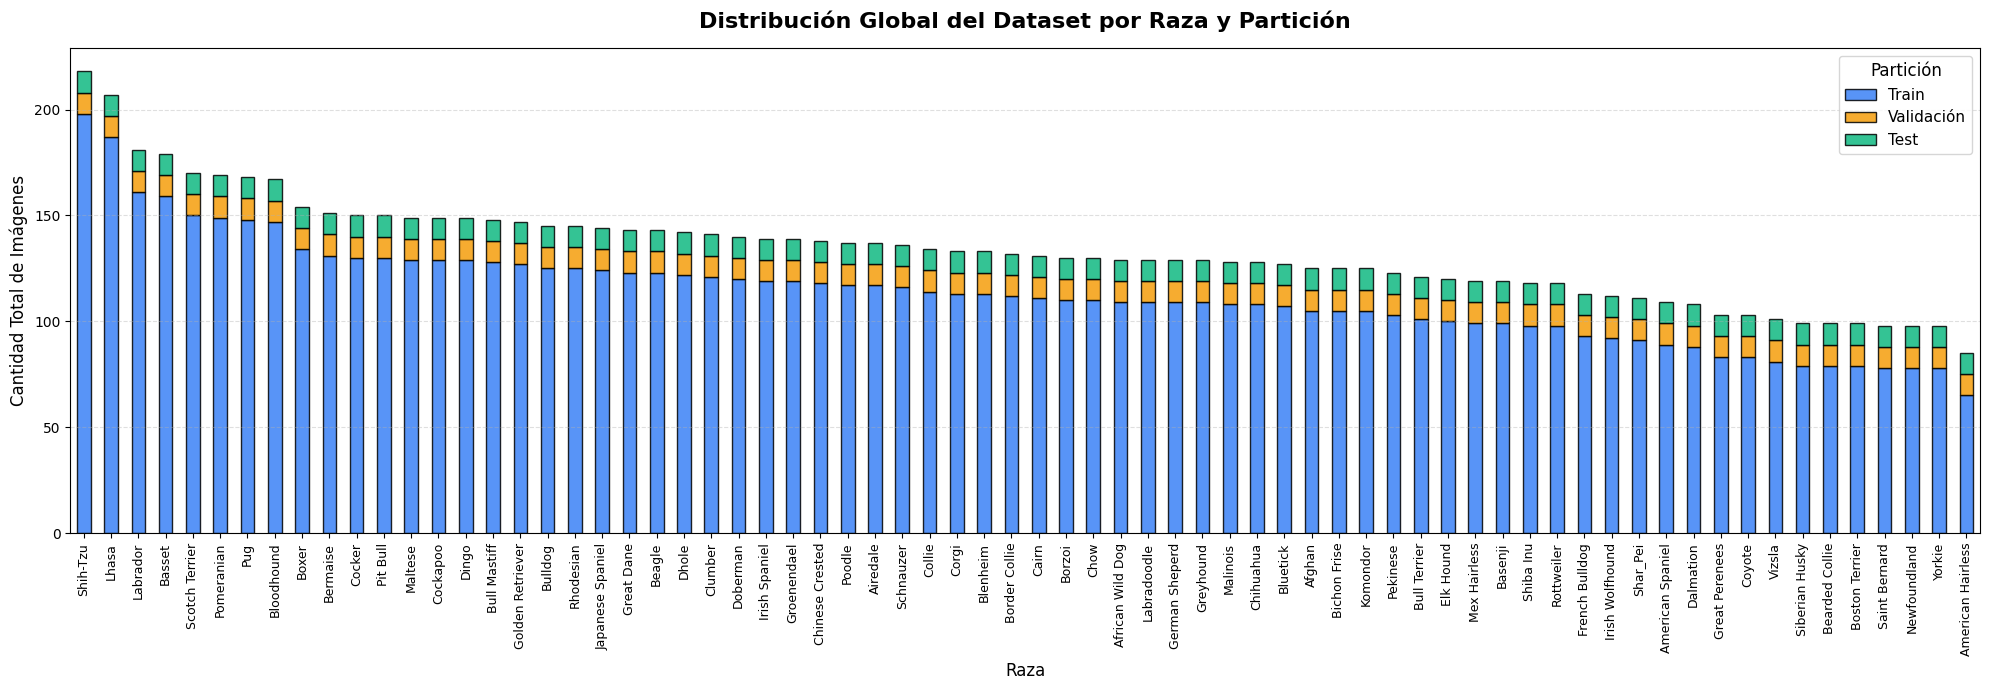

In [4]:
# Creamos el diccionario de mapeo ID -> Nombre de la raza
id_a_raza = {id_num: nombre for nombre, id_num in train_dataset.class_to_idx.items()}

#Contamos las etiquetas de cada partición
conteo_train = Counter(train_dataset.targets)
conteo_val = Counter(valid_dataset.targets)
conteo_test = Counter(test_dataset.targets)

# Consolidamos todo en un DataFrame
df_dist = pd.DataFrame({
    'Train': conteo_train,
    'Validación': conteo_val,
    'Test': conteo_test
    })

# Reemplazamos el índice numérico por los nombres usando nuestro id_a_raza
df_dist.index = [id_a_raza[i] for i in df_dist.index]

# Ordenamos de mayor a menor por total de imágenes
df_dist['Total'] = df_dist.sum(axis=1)
df_dist = df_dist.sort_values(by='Total', ascending=False)
df_dist = df_dist.drop(columns=['Total'])

#Graficamos
colores = ['#3b82f6', '#f59e0b', '#10b981']
plt.figure(figsize=(20, 7))

df_dist.plot(kind='bar', stacked=True, ax=plt.gca(), color=colores, edgecolor='black', alpha=0.85)

plt.title('Distribución Global del Dataset por Raza y Partición', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Raza', fontsize=12)
plt.ylabel('Cantidad Total de Imágenes', fontsize=12)

plt.xticks(rotation=90, fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title='Partición', fontsize=11, title_fontsize=12)

plt.tight_layout()
plt.show()

Basado en la distribución de clases, se observan las siguientes características en el conjunto de entrenamiento original:

*   **Clases Mayoritarias:** Las razas con mayor representación son **Shih-Tzu** (198 imágenes), **Lhasa** (187 imágenes) y **Labrador** (161 imágenes).
*   **Clases Minoritarias:** Las razas con menor cantidad de muestras iniciales son **American Hairless** (65 imágenes), **Yorkie** (78 imágenes) y **Saint Bernard** (78 imágenes).

Este desbalance de clases nos da pie a realizar un proceso de data augmentation para poder mitigar sesgos a la hora de entrenar a nuestros modelos.

A continuación verificaremos la cantidad de imagenes por clase en los conjuntos de Test y Validación

In [5]:
#Si tengo la misma cantidad de imagenes para cada raza, un unique debería retornar un unico elemento
cantidades_unicas_test = df_dist['Test'].unique()
cantidades_unicas_valid = df_dist['Validación'].unique()

if len(cantidades_unicas_test) == 1:
  print(f'El conjunto de test tiene {cantidades_unicas_test} imagenes por Raza')
  print(f'El conjunto de validación tiene {cantidades_unicas_valid} imagenes por Raza')

El conjunto de test tiene [10] imagenes por Raza
El conjunto de validación tiene [10] imagenes por Raza


Para poder adentrarnos un poco en el dataset que estaremos trabajando, haremos una observación inicial de las imágenes que utilizaremos para nuestro entrenamiento

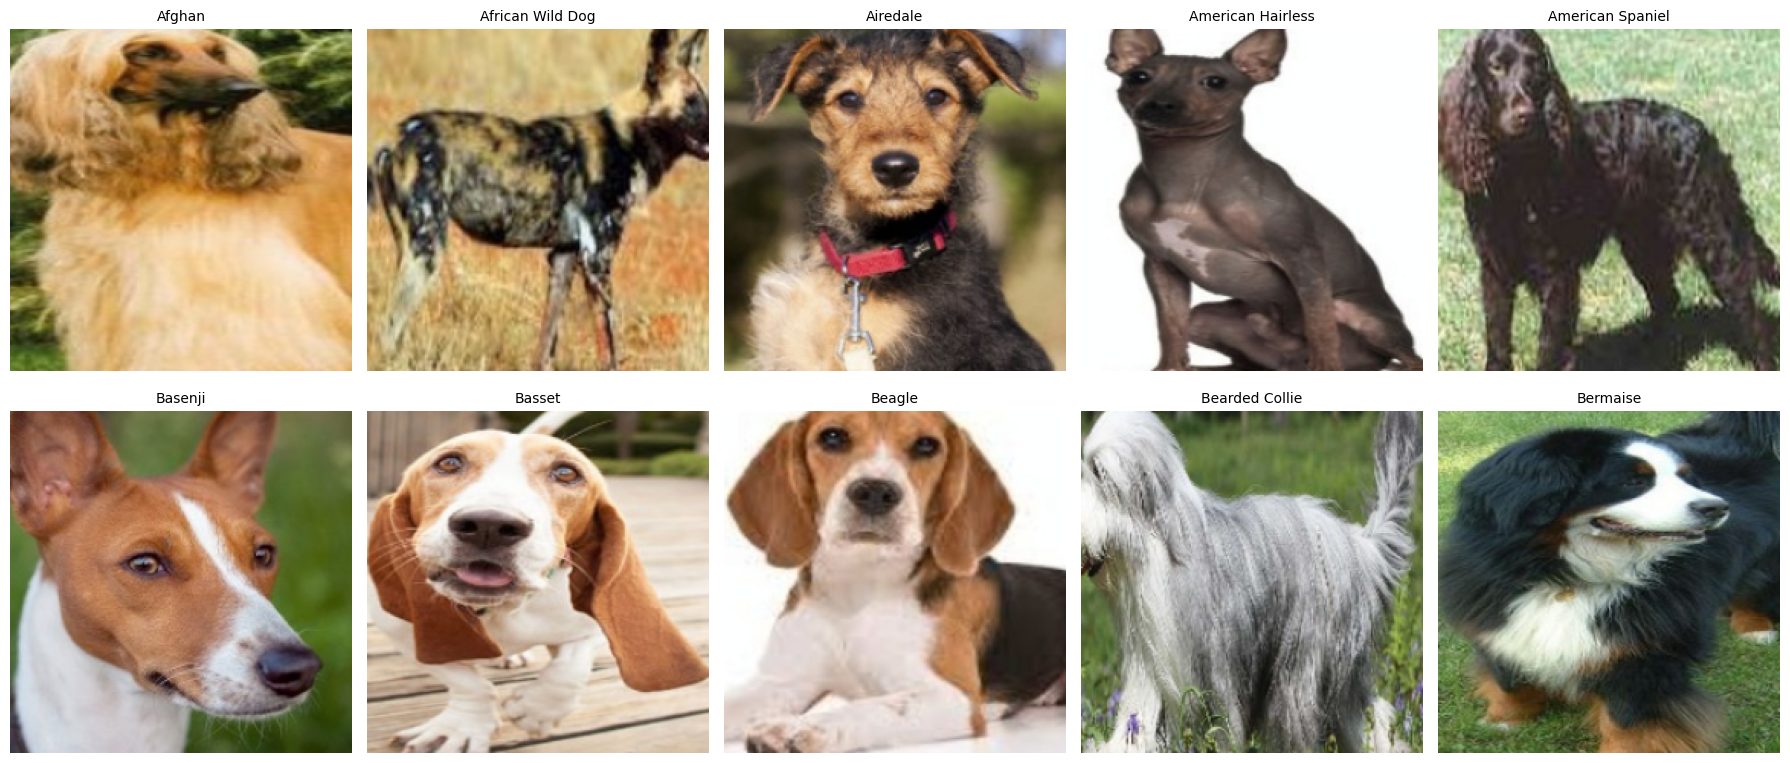

In [6]:
imagenes_a_mostrar = {}
for imagen, etiqueta in train_dataset:
    if etiqueta not in imagenes_a_mostrar:
        imagenes_a_mostrar[etiqueta] = imagen
    if len(imagenes_a_mostrar) == 10:
        break

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

for idx, (etiqueta, imagen) in enumerate(imagenes_a_mostrar.items()):
    nombre_raza = id_a_raza[etiqueta]

    img_para_mostrar = imagen.permute(1, 2, 0).numpy()

    img_para_mostrar = std * img_para_mostrar + mean
    img_para_mostrar = np.clip(img_para_mostrar, 0, 1)

    axes[idx].imshow(img_para_mostrar)
    axes[idx].set_title(nombre_raza, fontsize=10)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

Podemos observar, de manera preliminar, que hay mucha variedad en la composición de las imágenes, incluyendo tomas de cuerpo completo y planos de rasgos faciales. Esto puede ser visto como un desafío y, a su vez, como una ventaja. Si esta distribución de imágenes se mantiene para todos las las razas, es decir, tenemos planos frontales, laterales, de cuerpo completo y con foco en el rostro, vamos a estar forzando a nuestros modelos a aprender la representación completa de la raza. Teniendo en cuenta el funcionamiento de las capas convolucionales en la etapa de entrenamiento, el modelo, en teoría, será capaz de aprender desde descriptores generales como son las siluetas de cada raza, hasta descriptores locales muy específicos como pueden ser rasgos faciales, texturas de pelaje, entre otros.

## 3. Preprocesamiento

### 3.1 Preprocesamiento Inicial

Para asegurar un entrenamiento robusto y compatible con arquitecturas de vanguardia, hemos definido las siguientes estrategias:

1.  **Resize (256) y CenterCrop (224):**
    *   La mayoría de las arquitecturas pre-entrenadas (como ResNet18) esperan una entrada de 224x224. Redimensionar primero a 256 y luego recortar al centro ayuda a mantener el aspecto del objeto principal (el perro) eliminando ruido en los bordes.

2.  **Normalización (ImageNet):**
    *   Aplicamos `mean=[0.485, 0.456, 0.406]` y `std=[0.229, 0.224, 0.225]`. Esto es fundamental al usar Transfer Learning, ya que el modelo original fue entrenado con estas estadísticas y permite una convergencia más rápida.


### 3.2 Data Augmentation

Se realizará un proceso de data augmentation para lograr balancear la cantidad de imagenes por clase en el conjunto de entrenamiento y así evitar predicciones sesgadas hacia las clases mayoritarias. Para ello nos valemos de la libería Albumentations que nos permite hacer transformaciones geométricas, de color,y de desenfoque.

In [7]:
augmenter_albumentations = A.Compose([
    # Realiza una rotación horizontal
    A.HorizontalFlip(p=0.5),
    # Gira la imagen 15 grados
    # Safe rotate asegura que la enteridad de la imagen quede contenida dentro de una matriz del tamaño original
    # y que no se recorten accidentalmente partes de la foto al hacer la transformación
    A.SafeRotate(limit=15, p=0.8),
    # Cambia el brillo, contraste, saturación, intensidad y tono
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05, p=0.8),
    # Convierte a escala de grises
    A.ToGray(p=0.2),
    # Aplica un filtro de ruido gaussiano
    A.GaussianBlur(blur_limit=(3, 5), p=0.3)
])

El objetivo de realizar este tipo de data augmentation no es solamente aumentar el tamaño del dataset en sí, si no, mejorar la capacidad de generalización del modelo introduciendo nuevas formas de interpretar a una misma raza.

Las transformaciones geométricas 'SafeRotate' y 'HorizontalFlip' fuerzan al modelo a reconocer, por ejemplo, la silueta de una raza en específico sin tener en cuenta la orientación de la misma. Esto lo hace mucho más robusto a la hora de evaluar nuevas fotos, ya que no podemos asegurar el ángulo en que fue tomada ni la orientación del perro en la misma.

Las transformaciones de color, saturación, tono y brillo ('ColorJitter') en cambio, fuerzan a nuestro modelo a no depender de tan fuertemente de la información cromática, permitiendo que este se enfoque más en texturas y rasgos específicos de la raza. Ante nuevas fotos, esto nos permite mitigar, por ejemplo, las imagenes con flash, que contienen exceso de brillo o su caso contrario, imagenes con poca iluminación o mala exposición.

Finalmente las transformaciones de desenfoque, como es 'GaussianBlur', introducen ruido en la imagen de manera aleatoria, haciendo que nuestro modelo sea más robusto ante fotos de baja calidad, mal enfocadas, con movimiento, o con ruido digital.

## 4. Justificacion de los modelos elegidos

Etapa 1 - **Embeddings baseline**:
- Para la etapa 1, el modelo elegido es EfficientNet-B0, pre-entrenado en ImageNet. Se utiliza este modelo para la generación de embeddings debido a su precisión similar o superior a redes mucho más grandes (como ResNet-50) pero con una fracción del costo computacional con 5,3 millones de parámetros. 


Etapa 2 - **Modelo A (ResNet18 fine-tuned)**:
- Elejimos utilizar ResNet18 y no otro modelo más grande de la familia ResNet porque al estar haciendo transfer learning la diferencia de profundidad con los otros modelos no va a impactar tanto en la extracción de características. Las capas convolucionales del modelo ya están preentrenadas en ImageNet, en todos los casos, y capturan patrones generales, bordes, texturas, formas, que son suficientes para llevar a cabo la distinción entre razas. Además al contar con muchos menos parámetros que los otros modelos reducimos las posibilidades de overfitting al trabajar con dataset pequeño en relación con el que fue preentrenado ResNet.   

Etapa 2 - **Modelo B (CNN propia)**:
- Creamos una CNN propia con 4 bloques residuales (canales 64->128->256->512), convolución inicial de 7×7 con stride 2, seguida de MaxPooling, Global Average Pooling, Dropout(0.4) y capa lineal final para 70 clases. El diseño incorpora shortcuts en cada bloque para preservar la información y facilitar el flujo de los gradientes, siguiendo una arquitectura muy similar a ResNet. El modelo fue entrenado desde cero sin pesos preentrenados. La elección de una arquitectura moderada en profundidad responde a la necesidad de equilibrar capacidad de representación y limitaciones de cómputo disponibles, evitando un diseño más complejo que hubiera incrementado el costo de entrenamiento. Aun así, esta CNN sirve como baseline de comparación frente a modelos preentrenados, permitiendo demostrar el impacto positivo del transfer learning en tareas de clasificación de imágenes.

Etapa 3 - **YOLOv8m**:
-  Se eligio el modelo medium de la familia YOLOv8, pre-entrenado en COCO (que ya incluye la clase 'dog'). La idea detrás de la elección de este tamaño de modelo viene dada por la velocidad del modelo para hacer inferencia y su capacidad de detectar todos los perros presentes en las distintas imágenes con buenos scores de confianza.

## 5. Proceso de entrenamiento e hiperparametros

#### Mdelo A: ResNet18 Fine-tuned
- **Arquitectura**: ResNet18 pre-entrenado en ImageNet
- **Capa de clasificación**: Reemplazo de fc lineal (512 → 70 clases)
- **Optimizador**: Adam
- **Scheduler**: ReduceLROnPlateau (patience=5, mode='min')
- **Early Stopping**: Activado (paciencia=15)
- **Batch size**: 32 (Definido por variable de entorno BATCH_SIZE)
- **Épocas**: 100
- **Data augmentation**: HorizontalFlip, RandomBrightnessContrast, Rotate, ShiftScaleRotate, Normalize
- **Pérdida**: CrossEntropyLoss con pesos por clase para balancear

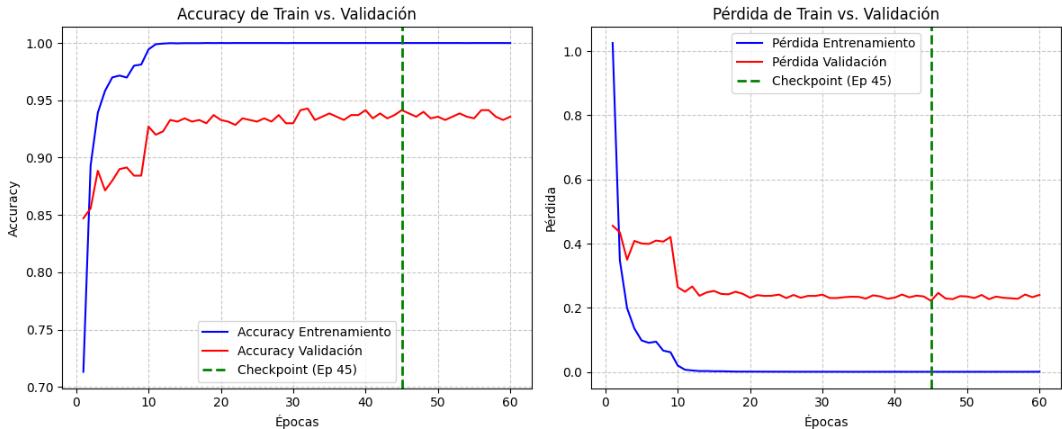

Podemos observar el estancamiento de las métricas a partir de la época 13 y evidenciar la acción del scheduler; la pérdida en validación se va estabilizando, lo que significa un descenso más suave por el gradiente en la búsqueda de un valor de pérdida mínimo.

#### Modelo B: CustomCNN con ResidualBlocks
- **Arquitectura**: 4 ResidualBlocks (64→128→256→512) + AvgPool + Dropout(0.4) + Linear(70 clases)
- **Learning Rate**: 0.001
- **Optimizador**: Adam
- **Scheduler**: ReduceLROnPlateau (patience=5, mode='min')
- **Early Stopping**: Activado (paciencia=15)
- **Batch size**: 32 (Definido por variable de entorno BATCH_SIZE)
- **Épocas**: 100
- **Data augmentation**: Idem Modelo A
- **Pérdida**: CrossEntropyLoss con pesos por clase

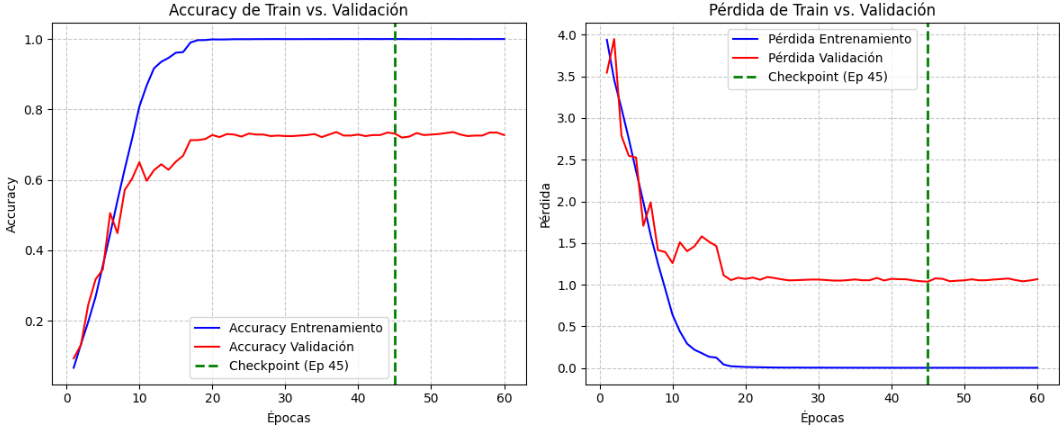

Podemos observar patrones de comportamiento muy similares a los de ResNet18, con la diferencia que nuestro modelo Custom, al haber sido entrenado desde cero con un dataset relativamente pequeño, encuentra un piso de pérdida en validación de 1.0 - 1.1 y un techo de accuracy del 73% - 74%. Teniendo en cuenta las limitaciones temporales y de hardware, consideramos que hemos logrado alcanzar valores respetables. Comprendemos que mejorar estas métricas requeriría no solo complejizar la arquitectura de la CNN, aumentando la cantidad de parámetros y, a su vez, los costos computacionales, sino que también demandaría un incremento exponencial en el volumen de imágenes de entrenamiento para cada clase.

## 6. Resultados obtenidos

### Etapa 1

Logramos un NDCG@10 promedio de 0.9718 sobre 700 imágenes, lo cual nos indica que nuestro sistema logra un muy buen desempeño en la gran mayoría de las razas.
En lo que respecta a las peores instancias tenemos casos como el  Bulldog con un 0.72 o el Labradoodle un 0.88, no significa necesariamente que el modelo falle, sino que refleja solapamientos visuales. Esto puede deberse a factores en el espacio de embeddings como:

- Razas como el Labradoodle (cruce de Labrador y Caniche) y el Cockapoo (Cocker y Caniche) son muy variadas por lo que en el espacio de características, los embeddings de un Labradoodle seguramente se estén mezclando en las fronteras de los clusters de los Caniches o Labradores puros, haciendo que el modelo traiga imágenes de las razas progenitoras en los primeros puestos.
- Razas como el Bulldog y el Boston Terrier comparten rasgos faciales muy marcados (cráneos anchos, hocicos cortos). Es probable que el modelo se esté fijando en estas formas estructurales fuertes y confunda ambas razas.

Las razas que obtuvieron un NDCG perfecto de 1.0 tienen características únicas y discriminativas para su raza. Como puede suceder con el Komondor (con su pelaje en forma de rastas/cordones), el African Wild Dog (con su patrón de manchas asimétricas redondas y grandes orejas) o el Bloodhound (con sus pliegues excesivos y orejas largas). Para el modelo, extraer los features de estas imágenes es una tarea sencilla porque no se parecen a ninguna otra raza. En tu espacio latente, estas clases forman clusters muy densos, compactos y totalmente aislados del resto.

### Etapa 2

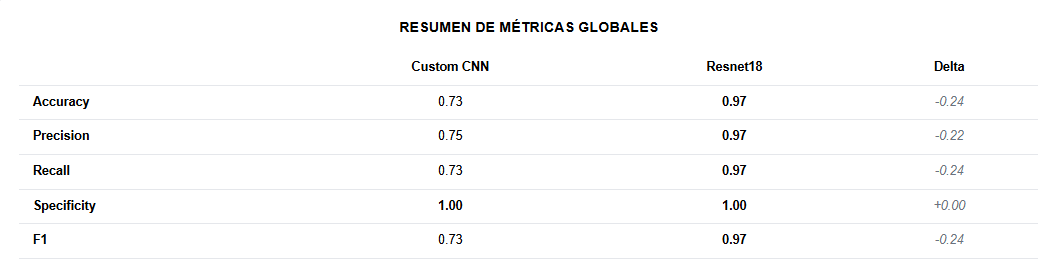

Podemos observar que nuestras métricas son muy elevadas en nuestro modelo ResNet18, esto nos da a entender que nuestro modelo tiene gran capacidad de generalización, refutando que el modelo esté sobreajustado.

Tener una especificidad perfecta nos indica que nuestro modelo presenta una ausencia de falsos positivos, ya que es la única manera, interpretando la fórmula, que esto pase. Esto es una ilusión, ya que si analizamos clase por clase la matriz de confusión, podemos observar existencia de falsos positivos. Lo más probable es que se deba a un error de redondeo decimal a dos cifras y nuestra especificidad real sea mayor a 0.995, pero menor que 1.

El resto de las métricas apoyan esta teoría, ya que si nuestra especificidad fuese exactamente uno, al realizarse un promedio de especificidad de todas las clases, indicaría que ninguna tiene falsos positivos, a su vez indica que ninguna otra tiene falsos negativos, y el resto de las métricas tendrían que tener el valor de uno exacto.

Las métricas, sin embargo, son excepcionalmente buenas ya que están basadas en los promedios de métricas por clase, también llamado promedio macro. Un F1-Score alto nos indica un muy buen balance entre precisión y recall, esto nos indica que nuestro modelo no está emitiendo en gran cantidad falsos positivos (precisión), ni está perdiendo verdaderos positivos (recall).

Teniendo en cuenta las métricas macro de nuestra CustomCNN, podemos observar que nuestro modelo realmente ha aprendido de los datos. Su conocimiento es más superficial comparado a ResNet18, pero es lo suficientemente competente teniendo en cuenta las limitaciones técnicas.

De todas maneras, logra detectar el 73% de los verdaderos positivos, basandonos en el recall. Esto implica que un 27% de las detecciones fueron asignadas como falsos negativos relativos a otras clases.

La precisión nos indica que del total de las detecciones, solo el 75% son efectivamente verdaderos positivos, lo que indica que ha asignado un 25% de falsos positivos a otras razas.

Observamos otra problemática de la especificidad macro, al ser un problema multiclase, tenemos 700 imagenes en el conjunto de test de las cuales solo 10 pertenecen verdaderamente a una clase específica. Esto nos dá una posibilidad de 690 verdaderos negativos, lo que termina dominando el cálculo dando siempre valores cercanos a 1. Si tuviesemos una clase que, de manera desproporcionada, tuviese una cantidad significativa de falsos positivos para influenciar esta métrica, significaría que esa clase estaría acumulando la mayoría de las predicciones, volviendo a nuestro modelo obsoleto.

Notamos una gran diferencia de desempeño entre el modelo ResNet18 y nuestra CNN Custom, siendo ResNet18 el mejor modelo para realizar inferencia.

Esto se debe en gran medida a que nuestra CNN Custom está entrenada desde cero, con un dataset pequeño, y una arquitectura más sencilla en relación a ResNet18. La potencia de ResNet18 está dada por sus pesos preentrenados, su costo computacional relativamente bajo a la hora de hacer fine-tuning y su gran capacidad de generalización una vez entrenado.

#### Matriz de confusión de ResNet fine-tuned

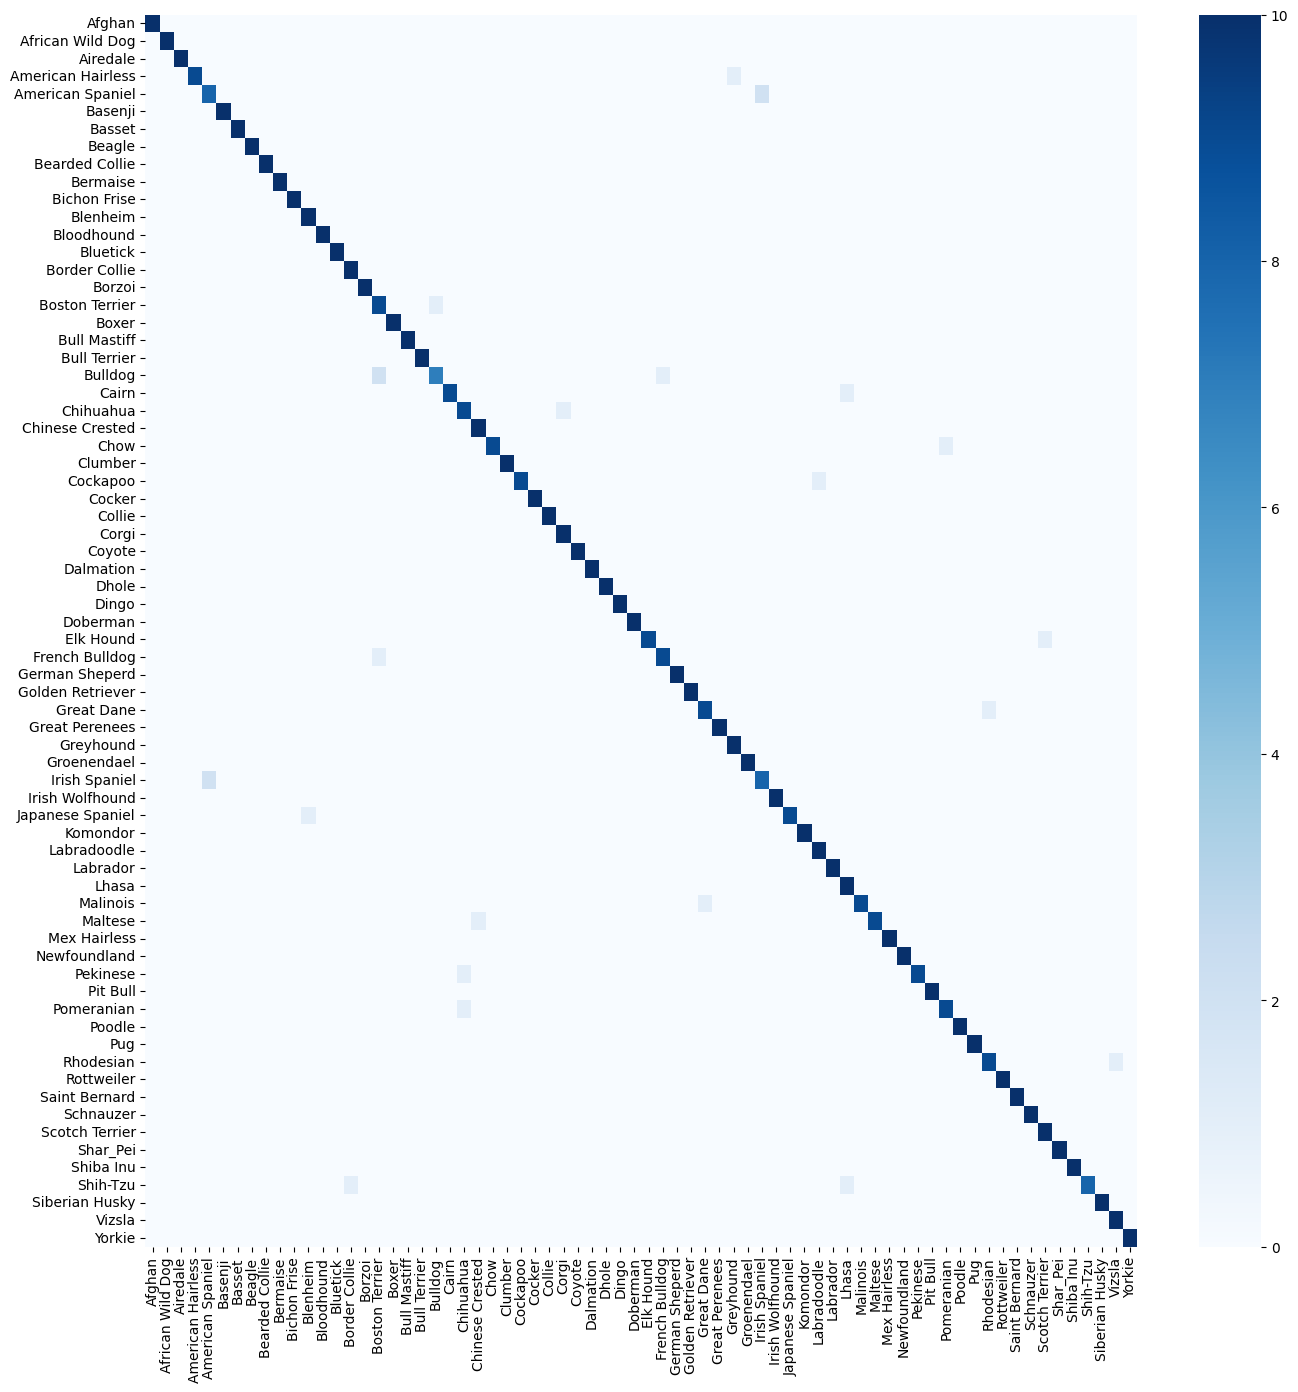

Confirmamos lo observado en las métricas, estamos ante la presencia de algunos, aunque pocos, falsos positivos para las clases American Spaniel, Border Collie, Lhasa, entre otros.

#### Matriz de confusión de CNNCustom

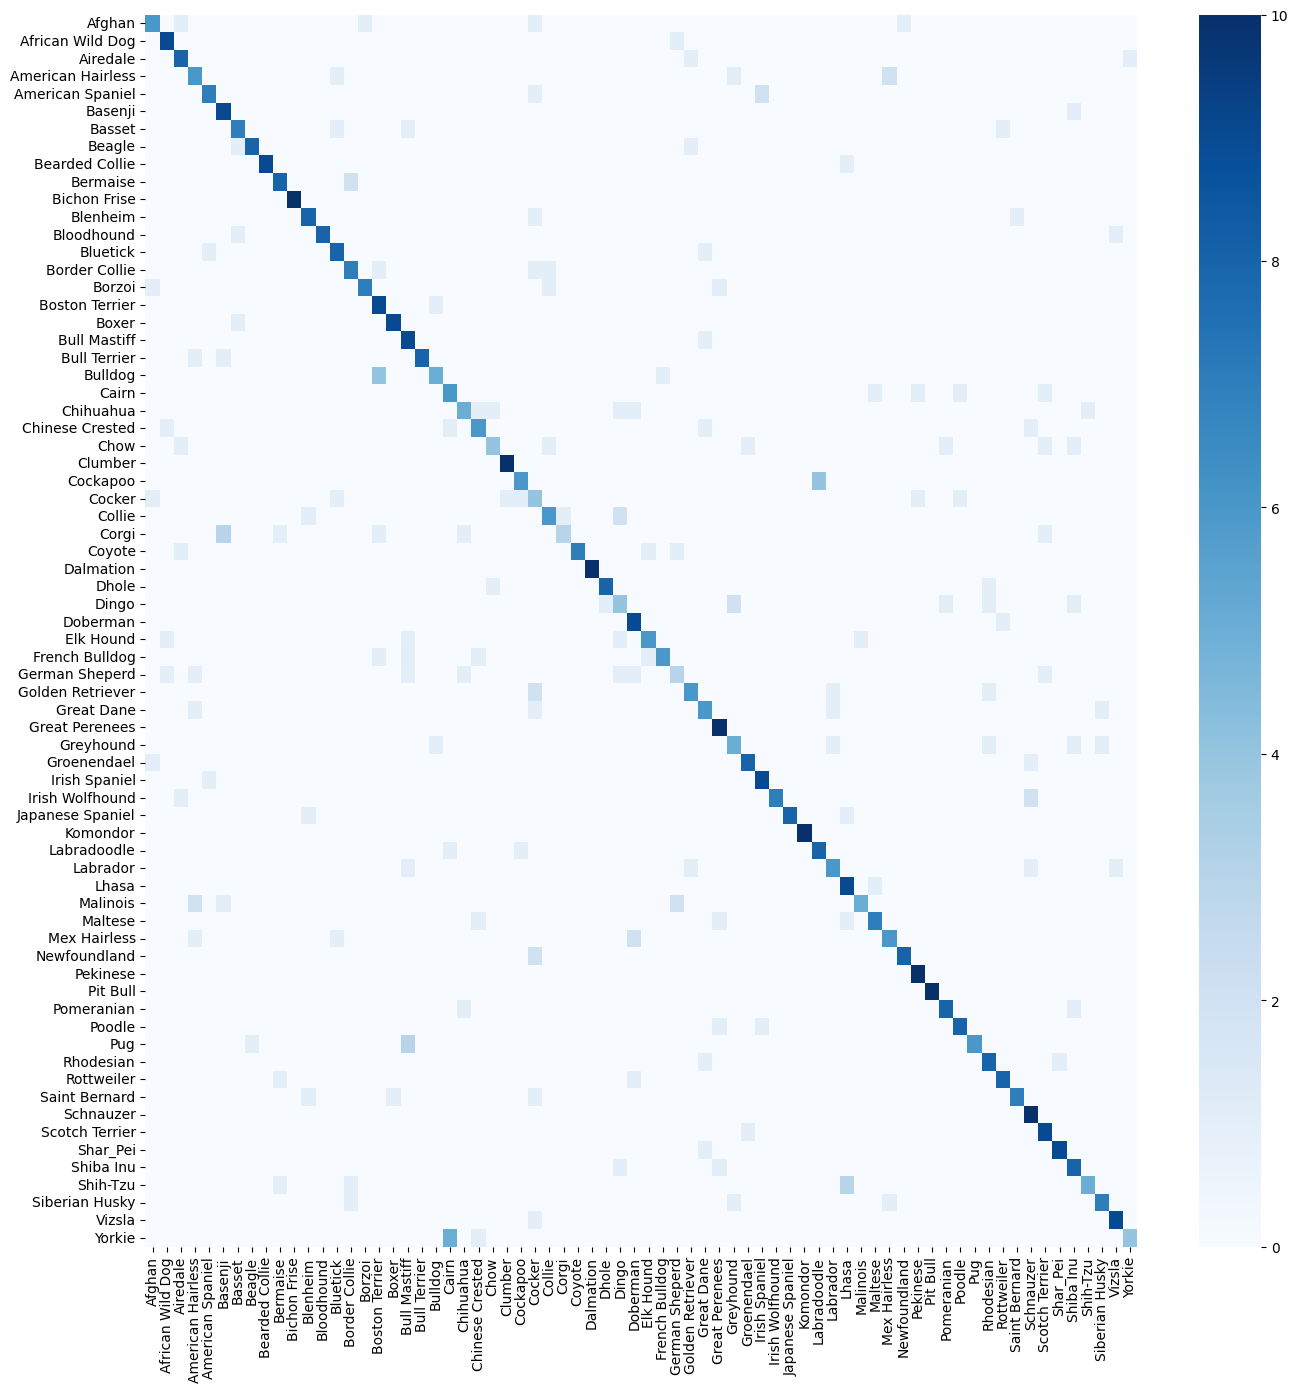

Podemos observar que tenemos una mayor cantidad de falsos positivos en relación a la matriz de confusión de ResNet18. Lo destacable es que por una exploración visual, podemos darnos cuenta que la mayoría de estos falsos positivos provienen de razas con características similares. Podemos teorizar que el modelo es bueno para distinguir tamaño y textura básica, en caso de Cairn y Yorkie ambos son perros pequeños y peludos, o características fuertes como por ejemplo, razas de hocicos chatos como lo son el bulldog, bulldog francés y los mastines.

La causa de estas confusiones tienen que ver con lo mencionado previamente, a nuestra CNN le falta la complejidad suficiente como para poder reconocer patrones más fuertes y granulares en relación a las razas, sumado al dataset pequeño de donde extraer esos patrones.

## 7. Comparacion entre enfoques

### Búsqueda por similitud vs Clasificacion supervisada

- **Búsqueda por similitud**: La búsqueda por similitud, realizada en la etapa 1, no requeire de entrenamiento, se vale de lso pesos preentrenados de un modelo EfficientNet-B0, para producir emebeddings que, una vez normalizados, serán almacenados en una base de datos vectorial. Este método nos permite permite recuperar imágenes similares sin la necesidad de pasar por el entrenaminto de un modelo pero esta recuperación depende mucho de la calidad de los embeddings generados puede fallar por la morfología similar entre diversas razas de perros.

- **Clasificacion supervisada**: La clasificación supervisada consta de un ResNet18 fine-tuned y una CNN custom. Si bien la CNN hecha es muy similar a ResNet no logra acercarcele en redimiento para nuestra aplicación. El modelo ResNet18 fien-tuned presenta gran superioridad ante la CNN no solo en cuestión me métricas, lo supera por casi un 40%, sino también por su implementación más sencilla puesto que no hay que idear una arquitectura desde cero sino utilizar pesos preentrenados y usar un nuevo head para lograr clasificaciones corectas con mayor presisción.

## 8. Problemas encontrados y soluciones implementadas

El primer desafío significativo al que enfrentamos durante la etapa de extracción de embeddings fue un cuello de botella en la persistencia de datos. Notamos que el procesamiento de cada embedding tardaba minutos, un tiempo desproporcionado considerando que la escritura de un embedding individual en la base de datos toma microsegundos. Tras analizar el flujo, identificamos que el problema radicaba en el método append. Al abrir y cerrar una nueva sesión por cada embedding que se pretendía agregar, el tiempo gastado en establecer la comunicación era mucho mayor que la velocidad de inserción. Para resolver esto, desarrollamos una función que toma la lista completa de embeddings con su respectiva metadata y los persiste en lotes utilizando una única conexión. Esta optimización nos permitió ahorrar muchísimo tiempo de cómputo.



El segundo problema surgió al analizar las métricas de similitud. Como paso previo a la persistencia en la base de datos, nosotros realizamos una normalización de los embeddings. La similitud del coseno está dada por $\text{sim}(A, B) = \frac{A \cdot B}{||A|| ||B||}$. Dado que nuestros vectores ya están normalizados, la magnitud de los mismos es siempre 1. En consecuencia, el denominador de la ecuación original se vuelve redundante y la operación matemática se reduce directamente al producto punto, siendo $\text{sim}(A, B) = A \cdot B$. Es por ello que decidimos implementar una función dot_product, que realiza el producto punto entre los embeddings de la base de datos y el embedding query.

A partir de esto, introdujimos un método llamado store.alt_search, el cual reemplaza el uso tradicional de store.search. Esta nueva función aprovecha la normalización previa para optimizar las consultas directamente en la base de datos, utilizando el operador de producto punto '<#>' en lugar del operador de coseno.

El tercer desafío consistió en los problemas de rendimiento y aprendizaje que presentó nuestra primera CNN. A pesar de tener una estructura estándar, el modelo tardaba demasiado en procesar cada época y no lograba converger en el tiempo estipulado. Esta ineficiencia se debió a que las primeras capas mantenían una resolución espacial muy alta que disparaba la cantidad de operaciones matemáticas y al uso de un aplanamiento tradicional que generaba una capa de clasificación con decenas de millones de parámetros.

La solución fue rediseñar por completo la arquitectura agregando conceptos basados en ResNet, logrando converger exitosamente y en una fracción del tiempo. Primero, implementamos una reducción espacial agresiva desde la entrada utilizando un kernel grande y agrupamiento máximo, ambos para reducir la dimensionalidad a la mitad, lo que alivianó inmediatamente la carga computacional del resto del modelo. Segundo, introdujimos bloques residuales con conexiones shortcut, creando vías directas para el flujo de gradientes que evitan el desvanecimiento y estabilizaron el aprendizaje. Finalmente, reemplazamos la red de conexiones finales por un agrupamiento promedio global, eliminando millones de parámetros redundantes, lo que resultó en un modelo más ligero y rápido.

## 9. Modificaciones fuera de las funciones indicadas

- **alt_search**: En 'pgvector_store.py' se anadió un nuevo método 'alt_search' que utilizamos para obtener los k vecinos más cercanos usando el producto punto (operador <#> de pgvector) ya que al haber nomalizados los embeddings previo a almacenarlso en la base de datos los métodos provistos no nos permitian calcular la similitud entre embeddings sin tener que modificarlos.

- **append_batch**: En 'pgvector_store.py' se anadió un nuevo método 'append_batch' que nos permite llevar a cabo la inserción de múltiples embeddings en una única operación, ignorando duplicados por id_imagen, mejorando de este modo la eficiencia al no tener que realizar una conexión a la base de datos cada vez que se almacena una única imagen.

- **truncate**: En 'pgvector_store.py' se anadió un nuevo método 'truncate' que nos permite eliminar todos los registros de la tabla de embeddings de forma permanente para así evitar duplicados si se corre nuevamente lal base de datos.

- **load_model**: En 'detection_service.py' se modificó el método 'load_model' para que cargue (con cache) el checkpoint del modelo indicado o del activo 